In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Pràctica 1: Dinàmica de l'aplicació logística.

L'objectiu d'aquesta pràctica és visualitzar certs fenòmens complexos provinents de la iteració de l'aplicació logística.

En particular: 

1. Calcularem el diagrama de bifurcació conegut com a "Period Doubling Cascade", on per cada valor del paràmetre observarem l'atractor dinàmic corresponent.
2. Calcularem l'exponent de Lyapunov per tal d'evidenciar l'existència d'atractors estranys i validar la presència de dinàmica caòtica.

En tota la pràctica, considerem el sistema dinàmic discret donat per $x_{n+1}=f_{\lambda}(x_n)$ amb $$f_{\lambda}(x)=\lambda x (1-x),\quad \lambda\in[1,4].$$

#### Exercici 1. Argumenta que si $x\in[0,1]$ aleshores $f_{\lambda}^k(x)\in[0,1]$ per a tot $k\in\mathbb{N}$ quan $\lambda\in[1,4]$, però que això deixa de ser cert si $\lambda>4$.

#### Exercici 2. Pren un valor $x\in(0,1)$ aleatori i per cada $\lambda\in\{1.00,1.01,1.02,\dots,3.99,4.00\}$ calcula els punts $(\lambda,f_{\lambda}^k(x))$ amb $1000<k\leq 1100$. Representa aquests punts en el pla cartesià ($\lambda$ a l'eix horitzontal i $f_{\mu}^k(x)$ a l'eix vertical).

La gràfica que obtindràs es coneix com a *diagrama de bifurcació de la dinàmica* i dóna informació sobre com canvia el comportament asimptòtic de la dinàmica del sistema dinàmic a mesura que varia el paràmetre $\lambda$.

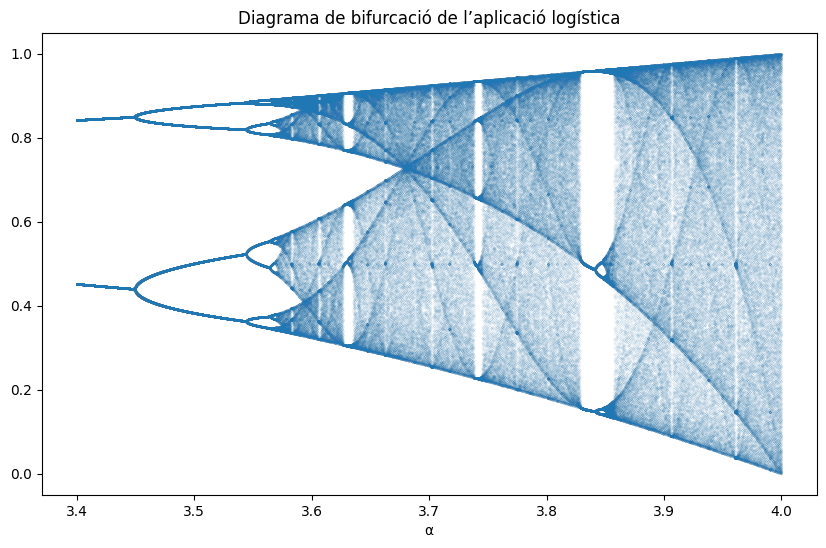

In [9]:
def F(alpha, x):
    return alpha*x*(1-x)
    
x0 = np.random.rand()
alphas = np.arange(3.4, 4.00, 0.0001)
n_final = 1100
n_transitori = 1000

alpha_vals = []
x_vals = []

for alpha in alphas:
    x = x0
    for k in range(n_final):
        x = F(alpha, x)
        if k > n_transitori:
            alpha_vals.append(alpha)
            x_vals.append(x)

plt.figure(figsize=(10, 6))
plt.scatter(alpha_vals, x_vals, s=0.001)
plt.xlabel('α')
plt.title('Diagrama de bifurcació de l’aplicació logística')
plt.show()

Si repeteixes la gràfica anterior canviar el nombre aleatori inicial, obtindràs essencialment el mateix. Això es degut a que per $\lambda\in[0,4]$ l'aplicació logística només té un atractor contingut a l'interval $[0,1]$. Aleshores, tota condició inicial convergeix al mateix atractor, que és el que s'observa a la gràfica. Els únics punts que no convergeixen a aquest atractor són els punts fixos inestables i les òrbites periòdiques inestables.

Recorda que pots fer un zoom numèric simplement canviant el rang de $\lambda$ i aumentant el pas de la discretització del rang. Fes un zoom apropiat del diagrama anterior per $\lambda\in(3.4,4)$.

#### Exercici 3. Basant-te en la gràfica anterior dona intervals aproximats del paràmetre $\lambda$ en els que:
1. L’atractor al qual convergeixen les semiòrbites positives és un punt fix.
2. L’atractor al qual convergeixen les semiòrbites positives és un òrbita 2 periòdica.
3. L’atractor al qual convergeixen les semiòrbites positives és una òrbita 4 periòdica.

Explica com dedueixes, a partir de la gràfica, que la semiòrbita positiva de la condició inicial convergeix a un punt fix o a una òrbita periòdica.

## Apartat d)

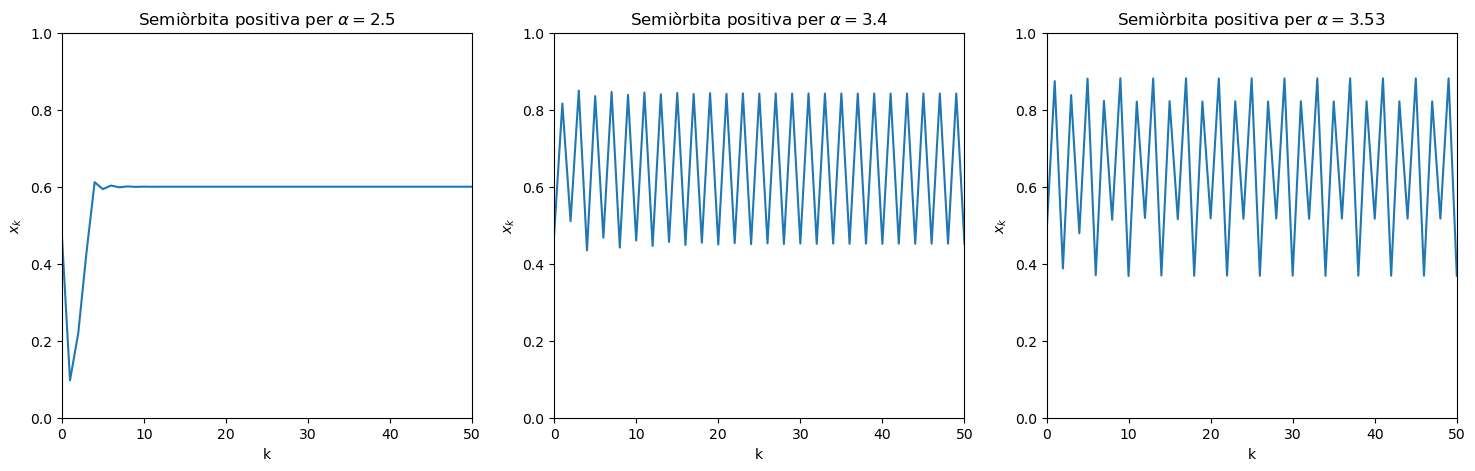

In [59]:
x0 = np.random.rand()

fig, axes = plt.subplots(1, 3, figsize=(18,5))

x_vals = [x0]
alpha = 2.5
for k in range(50):
    x = F(alpha,x)
    x_vals.append(x)
axes[0].plot(x_vals)
axes[0].set_xlabel('k')
axes[0].set_ylabel('$x_k$')
axes[0].set_title('Semiòrbita positiva per $α=2.5$')
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 1)

x_vals = [x0]
alpha = 3.4

for k in range(50):
    x = F(alpha,x)
    x_vals.append(x)
axes[1].plot(x_vals)
axes[1].set_xlabel('k')
axes[1].set_ylabel('$x_k$')
axes[1].set_title('Semiòrbita positiva per $α=3.4$')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 1)

x_vals = [x0]
alpha = 3.53

for k in range(50):
    x = F(alpha,x)
    x_vals.append(x)
axes[2].plot(x_vals)
axes[2].set_xlabel('k')
axes[2].set_ylabel('$x_k$')
axes[2].set_title('Semiòrbita positiva per $α=3.53$')
axes[2].set_xlim(0, 50)
axes[2].set_ylim(0, 1)

plt.show()

## Apartat e)

In [64]:
def dF(alpha,x):
    return alpha*(1-2*x)

def lyap(alpha,x):
    for k in range(1000):
        x = F(alpha,x)
    lam = np.log(abs(dF(alpha,x)))
    for k in range(5000):
        x = F(alpha,x)
        lam = lam + np.log(np.abs(dF(alpha,x)))
    lam = lam/k
    return lam  

## Apartat f)

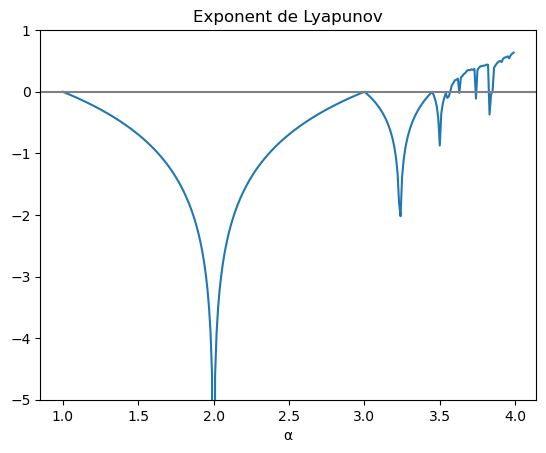

In [70]:
x0 = np.random.rand()
alphas = np.arange(1, 4.00, 0.01)
lyap_vals = []

for alpha in alphas:
    lyap_vals.append(lyap(alpha,x0))

plt.plot(alphas, lyap_vals)
plt.axhline(0, color='grey')
plt.xlabel('α')
plt.title('Exponent de Lyapunov')
plt.ylim(-5,1)
plt.show()

## Apartat g)

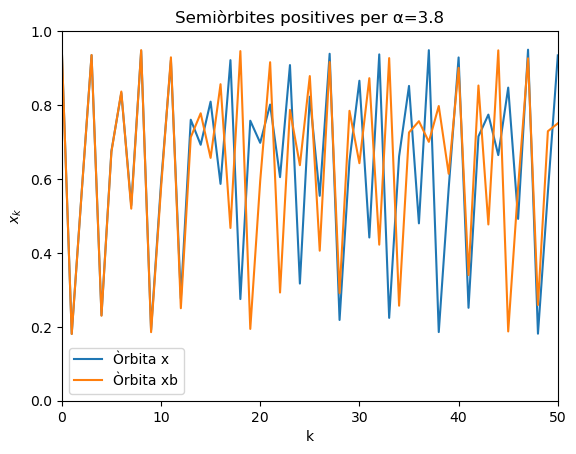

In [93]:
x = np.random.rand()
xb = max(0,min(1,x+0.0001))
alpha = 3.8

x_vals = [x]
xb_vals = [xb]

for k in range(50):
    x = F(alpha,x)
    xb = F(alpha,xb)
    x_vals.append(x)
    xb_vals.append(xb)

plt.plot(x_vals, label='Òrbita x')
plt.plot(xb_vals, label='Òrbita xb')
plt.xlabel('k')
plt.ylabel('$x_k$')
plt.title('Semiòrbites positives per α=3.8')
plt.xlim(0, 50)
plt.ylim(0, 1)
plt.legend()

plt.show()